# Mini Trabalho DAA


## Ano Letivo 25/26

### Trabalho Realizado por:


*   Daniel Silva, nº 129859
*   Francisco Silva, nº 129868
*   Rodrigo Cruz, nº 129829

# Análise de Redes

Neste trabalho, no âmbito da unidade curricular de Desenho e Análise de Algoritmos (DAA), analisamos redes de co-ocorrências de personagens de dois universos ficcionais: a saga A Song of Ice and Fire (Game of Thrones) e o universo Marvel Comics.

O objetivo foi implementar de raiz em Python um conjunto de métricas estatísticas para grafos não orientados, organizadas numa API chamada `CentralityAnalyzer`. Não utilizámos bibliotecas externas de grafos (como networkx ou igraph) — partimos da classe `Graph` desenvolvida nas aulas práticas.

O trabalho está organizado em:

* **Análise Estrutural** — BFS, componentes conexas, distribuição de graus e diâmetro;
* **Métricas de Centralidade** — Degree Centrality, Closeness Centrality, Eigenvector Centrality (Power Iteration) e Betweenness Centrality (Brandes);
* **Análise de Escalabilidade** — estudo empírico do tempo de execução nos quatro datasets fornecidos (de 187 a 6421 vértices).





##   Bibliotecas usadas







In [101]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import random
from collections import deque
import matplotlib.ticker as ticker
import csv

## TDA Graph

Código adaptado das aulas da semana 7.


In [102]:
class Vertex:
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id

    def __hash__(self):
        return hash(self._vertex_id)

    def __str__(self):
        return 'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        return self._vertex_id == vertex._vertex_id

    def vertex_id(self):
        return self._vertex_id


class Edge:
    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        return hash((self._vertex_1, self._vertex_2))

    def __str__(self):
        return 'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def endpoints(self):
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        return self._weight

    def opposite(self, vertex):
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None


class Graph:
    def __init__(self):
        self._adjancencies = {}
        self._vertices = {}
        self._n = 0
        self._m = 0

    def __str__(self):
        if self._n == 0:
            return "DAA-Graph: <empty>\n"
        ret = "DAA-Graph:\n"
        for vertex in self._adjancencies.keys():
            ret += str(vertex) + ": "
            for edge in self.incident_edges(vertex.vertex_id()):
                ret += str(edge) + "; "
            ret += "\n"
        return ret

    def order(self):
        return self._n

    def size(self):
        return self._m

    def has_vertex(self, vertex_id):
        return vertex_id in self._vertices

    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return vertex_v in self._adjancencies[vertex_u]

    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)
            self._vertices[vertex_id] = vertex
            self._adjancencies[vertex] = {}
            self._n += 1

    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id)
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id)
        if not self.has_edge(u_id, v_id):
            self._m += 1
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        e = Edge(vertex_u, vertex_v, weight)
        self._adjancencies[vertex_u][vertex_v] = e
        self._adjancencies[vertex_v][vertex_u] = e

    def degree(self, vertex_id):
        return len(self._adjancencies[self._vertices[vertex_id]])

    def get_vertex(self, vertex_id):
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id]

    def get_edge(self, u_id, v_id):
        if not self.has_edge(u_id, v_id):
            return None
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return self._adjancencies[vertex_u][vertex_v]

    def vertices(self):
        return self._vertices.values()

    def edges(self):
        seen = {}
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values():
            yield edge

    def remove_vertex(self, vertex_id):
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id))
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())
            del self._adjancencies[self._vertices[vertex_id]]
            del self._vertices[vertex_id]
            self._n -= 1

    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v:
                del self._adjancencies[vertex_v][vertex_u]
            self._m -= 1

    @staticmethod
    def from_csv(filepath):
        g = Graph()
        with open(filepath, newline='', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            # --- INÍCIO DA ALTERAÇÃO ---
            # Identificar a chave correta do peso (maiúscula/minúscula)
            weight_key = None
            if reader.fieldnames:
                for name in reader.fieldnames:
                    if name.strip().lower() == 'weight':
                        weight_key = name
                        break
            # --- FIM DA ALTERAÇÃO ---
            for row in reader:
                src = row['Source'].strip()
                tgt = row['Target'].strip()
                # Usar a chave encontrada ou 1 se não existir
                w = float(row.get(weight_key, 1)) if weight_key else 1.0
                g.insert_edge(src, tgt, w)
        return g


## 1. API CentralityAnalyzer

In [103]:
#API para análise de centralidade de grafos ficcionais.
class CentralityAnalyzer:

    # Recebe um objecto Graph já construído (por Graph.from_csv).
    def __init__(self, graph: Graph):
        self._graph = graph
        self._n = graph.order()
        self._m = graph.size()
        self._nodes = [v.vertex_id() for v in graph.vertices()]

    def bfs(self, source):
        """
        Travessia em largura a partir de `source`.
        Devolve (dist, pred):
          - dist: dict {v -> distância BFS de source a v}
          - pred: dict {v -> predecessor na BFS tree}
        """
        dist = {source: 0}
        pred = {source: None}
        queue = deque([source])
        while queue:
            u_id = queue.popleft()
            u_vertex = self._graph.get_vertex(u_id)
            for v_vertex in self._graph._adjancencies[u_vertex]:
                v_id = v_vertex.vertex_id()
                if v_id not in dist:
                    dist[v_id] = dist[u_id] + 1
                    pred[v_id] = u_id
                    queue.append(v_id)
        return dist, pred

    def num_components(self):
        visited = set()
        count = 0
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                count += 1
                dist, _ = self.bfs(v_id)
                visited.update(dist.keys())
        return count

    def largest_component(self):
        visited = set()
        largest_nodes = []
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                dist, _ = self.bfs(v_id)
                nodes = list(dist.keys())
                if len(nodes) > len(largest_nodes):
                    largest_nodes = nodes
                visited.update(nodes)
        new_g = Graph()
        nodes_set = set(largest_nodes)
        for u_id in largest_nodes:
            new_g.insert_vertex(u_id)
        seen_edges = set()
        for u_id in largest_nodes:
            for edge in self._graph.incident_edges(u_id):
                if edge in seen_edges:
                    continue
                v1, v2 = edge.endpoints()
                v1_id, v2_id = v1.vertex_id(), v2.vertex_id()
                if v1_id in nodes_set and v2_id in nodes_set:
                    new_g.insert_edge(v1_id, v2_id, edge.cost())
                    seen_edges.add(edge)
        return new_g

    def degree_distribution(self):
        """
        [Ponto 2.3] Calcula a distribuição de graus do grafo.
        Retorna um dicionário onde a chave é o grau e o valor é a frequência.
        """
        distrib = {}
        for v_id in self._nodes:
            deg = self._graph.degree(v_id)
            distrib[deg] = distrib.get(deg, 0) + 1
        return distrib

    def get_top_10_degree(self):
        deg_list = [(v_id, self._graph.degree(v_id)) for v_id in self._nodes]
        deg_list.sort(key=lambda x: x[1], reverse=True)
        return deg_list[:10]

    def diameter(self):
        """
        [Ponto 2.4] Diâmetro da maior componente conexa.
        Primeiro extrai a maior componente e depois executa BFS a partir de cada vértice.
        """
        lc = self.largest_component()
        lc_nodes = [v.vertex_id() for v in lc.vertices()]
        lc_analyzer = CentralityAnalyzer(lc)
        max_dist = 0
        for v_id in lc_nodes:
            dist, _ = lc_analyzer.bfs(v_id)
            current_max = max(dist.values()) if dist else 0
            if current_max > max_dist:
                max_dist = current_max
        return max_dist

    # --- 2. Métricas de Centralidade ---

    def degree_centrality(self):
        res = {}
        denominador = self._n - 1 if self._n > 1 else 1
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            res[v_id] = self._graph.degree(v_id) / denominador
        return res

    def get_top_10_dc(self):
        dc_list = list(self.degree_centrality().items())
        dc_list.sort(key=lambda x: x[1], reverse=True)
        return dc_list[:10]

    def closeness_centrality(self):
        res = {}
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            dist, _ = self.bfs(v_id)
            sum_dist = sum(dist.values())
            n_reached = len(dist)
            if sum_dist > 0 and n_reached > 1:
                proporcao_nos = (n_reached - 1) / (self._n - 1)
                dist_media_inv = (n_reached - 1) / sum_dist
                res[v_id] = proporcao_nos * dist_media_inv
            else:
                res[v_id] = 0.0
        return res

    def eigenvector_centrality(self, max_iter=100, tol=1e-6):
        """
        Retorna (scores_dict, k) onde k é o número de iterações realizadas.
        """
        if self._n == 0:
            return {}, 0
        x = {node: 1.0 / self._n for node in self._nodes}
        k = 0
        for _ in range(max_iter):
            k += 1
            x_last = x.copy()
            for u_id in self._nodes:
                total = 0
                for edge in self._graph.incident_edges(u_id):
                    v1, v2 = edge.endpoints()
                    v_id = v2.vertex_id() if v1.vertex_id() == u_id else v1.vertex_id()
                    total += x_last[v_id]
                x[u_id] = total
            norm = math.sqrt(sum(v**2 for v in x.values()))
            if norm == 0:
                break
            for u_id in x:
                x[u_id] /= norm
            error = sum(abs(x[u_id] - x_last[u_id]) for u_id in self._nodes)
            if error < tol:
                break
        return x, k

    def betweenness_centrality(self):
        """
        [Ponto 3.4] Algoritmo de Brandes para grafos não pesados.
        """
        betweenness = {v_id: 0.0 for v_id in self._nodes}
        for s in self._nodes:
            S = []
            P = {v_id: [] for v_id in self._nodes}
            sigma = {v_id: 0.0 for v_id in self._nodes}
            sigma[s] = 1.0
            d = {v_id: -1 for v_id in self._nodes}
            d[s] = 0
            queue = deque([s])
            while queue:
                v = queue.popleft()
                S.append(v)
                for edge in self._graph.incident_edges(v):
                    v1, v2 = edge.endpoints()
                    w = v2.vertex_id() if v1.vertex_id() == v else v1.vertex_id()
                    if d[w] < 0:
                        d[w] = d[v] + 1
                        queue.append(w)
                    if d[w] == d[v] + 1:
                        sigma[w] += sigma[v]
                        P[w].append(v)
            delta = {v_id: 0.0 for v_id in self._nodes}
            while S:
                w = S.pop()
                for v in P[w]:
                    delta[v] += (sigma[v] / sigma[w]) * (1.0 + delta[w])
                if w != s:
                    betweenness[w] += delta[w]
        for v in betweenness:
            betweenness[v] /= 2.0
        return betweenness

    def _path(self, source, target):
        """Devolve a sequência de vértices do caminho mínimo source -> target (BFS)."""
        _, pred = self.bfs(source)
        if target not in pred:
            return None
        path = []
        v = target
        while v is not None:
            path.append(v)
            v = pred[v]
        path.reverse()
        return path

### Validação dos métodos estruturais (grafo de teste)

In [104]:
# Grafo manual:
#   0 -- 1 -- 2     (componente 1)
#   3 -- 4          (componente 2)
g_test = Graph()
g_test.insert_edge('0', '1')
g_test.insert_edge('1', '2')
g_test.insert_edge('3', '4')
analyzer_test = CentralityAnalyzer(g_test)

# num_components
nc = analyzer_test.num_components()
print(f"Número de componentes: {nc} (esperado 2)")

# largest_component
lc = analyzer_test.largest_component()
print(f"Ordem da maior componente: {lc.order()} (esperado 3)")
print(f"Tamanho da maior componente: {lc.size()} (esperado 2)")

# Diâmetro da maior componente
diam = analyzer_test.diameter()
print(f"Diâmetro da maior componente: {diam} (esperado 2)")
# Caminho mais longo: '0' ↔ '2'
lct = CentralityAnalyzer(lc)
path_d = lct._path('0', '2')
print(f"Caminho diametral: {' → '.join(path_d)} (comprimento 2)")

Número de componentes: 2 (esperado 2)
Ordem da maior componente: 3 (esperado 3)
Tamanho da maior componente: 2 (esperado 2)
Diâmetro da maior componente: 2 (esperado 2)
Caminho diametral: 0 → 1 → 2 (comprimento 2)


# 1.2. Construtor e estrutura de dados utilizada

O construtor `__init__` recebe um objeto `Graph` já instanciado a partir de um CSV e guarda internamente a referência ao grafo, a sua ordem ($n$) e tamanho ($m$).

**Estimativa de espaço de memória:**

A representação utilizada é baseada em dicionários de adjacências (adjacency maps). O espaço total é $O(n + m)$:

* **Dicionário de vértices**: $n$ entradas, cada uma associando um ID ao respetivo objeto `Vertex` → $O(n)$.
* **Dicionário de adjacências**: estrutura de "dicionário de dicionários". Como o grafo é não orientado, cada aresta $\{u, v\}$ é guardada duas vezes (uma no mapa de $u$ e outra no de $v$), dando $2m$ entradas no total → $O(m)$.
* **Atributos numéricos** (`self._n`, `self._m`): espaço constante $O(1)$.

Esta representação é boa para os nossos datasets porque são grafos esparsos — o número de arestas é muito inferior a $n^2$. Uma matriz de adjacência para o `marvel_full` (6421 vértices) ocuparia cerca de 40 milhões de entradas, enquanto os dicionários guardam apenas as relações que existem de facto.


# 2.1. BFS

Implementámos o método `bfs(source)` que faz uma travessia em largura a partir de um vértice fonte, devolvendo as distâncias e predecessores de cada vértice alcançado.

* **Estrutura auxiliar**: Usámos a classe `collections.deque` como fila FIFO. O `deque` permite `popleft()` e `append()` em $O(1)$, ao contrário das listas Python onde remover do início custa $O(n)$.

* **Complexidade Temporal**: $O(n + m)$ — cada vértice entra e sai da fila uma vez ($O(n)$), e para cada vértice percorremos as suas adjacências. Como o grafo é não orientado, cada aresta é vista duas vezes, o que dá $O(m)$ no total.

* **Complexidade Espacial**: $O(n)$ para os dicionários de distâncias, predecessores e a fila.


# 2.2. Conectividade

* Metodologia: A identificação das componentes conexas é feita através de múltiplas execuções do BFS. O método `num_components` percorre todos os vértices e, sempre que encontra um que ainda não foi visitado, lança uma BFS — todos os nós alcançados pertencem à mesma componente. O `largest_component` faz o mesmo, mas guarda os nós da maior componente para construir um novo subgrafo.

* Complexidade Temporal: $O(n + m)$. Apesar de haver múltiplos ciclos, cada vértice e aresta são visitados um número constante de vezes graças ao conjunto `visited`.

* Complexidade Espacial: $O(n + m)$ para guardar os nós da nova componente e o conjunto de visitados.

Nos resultados abaixo, aplicamos estes métodos aos datasets `got_book1.csv` e `got_full.csv`. Verificamos também se dois personagens específicos estão conectados e mostramos o caminho entre eles.


In [105]:
# === Secção 2.2 – Conectividade ===
graph_book1 = Graph.from_csv('got_book1.csv')
graph_full  = Graph.from_csv('got_full.csv')

analyzer_book1 = CentralityAnalyzer(graph_book1)
analyzer_full  = CentralityAnalyzer(graph_full)

# ---- got_book1 ----
n_comp_b1 = analyzer_book1.num_components()
lc_b1     = analyzer_book1.largest_component()
lc_b1_analyzer = CentralityAnalyzer(lc_b1)

print("=== got_book1.csv ===")
print(f"  Vértices totais      : {graph_book1.order()}")
print(f"  Arestas totais       : {graph_book1.size()}")
print(f"  Componentes conexas  : {n_comp_b1}")
print(f"  Maior componente     : {lc_b1.order()} vértices / {lc_b1.size()} arestas")
print(f"  Vértices isolados    : {graph_book1.order() - lc_b1.order()}")

# ---- got_full ----
n_comp_f = analyzer_full.num_components()
lc_f     = analyzer_full.largest_component()
lc_f_analyzer = CentralityAnalyzer(lc_f)

print()
print("=== got_full.csv ===")
print(f"  Vértices totais      : {graph_full.order()}")
print(f"  Arestas totais       : {graph_full.size()}")
print(f"  Componentes conexas  : {n_comp_f}")
print(f"  Maior componente     : {lc_f.order()} vértices / {lc_f.size()} arestas")
print(f"  Vértices isolados    : {graph_full.order() - lc_f.order()}")

# ---- Caminho entre dois personagens em got_book1 ----
print()
src, tgt = 'Eddard-Stark', 'Daenerys-Targaryen'
path = analyzer_book1._path(src, tgt)
if path:
    print(f"Caminho entre {src} e {tgt}:")
    print("  " + " → ".join(path))
    print(f"  Distância: {len(path)-1} saltos")
else:
    print(f"Sem caminho entre {src} e {tgt}")

print()
src2, tgt2 = 'Jon-Snow', 'Cersei-Lannister'
path2 = analyzer_book1._path(src2, tgt2)
if path2:
    print(f"Caminho entre {src2} e {tgt2}:")
    print("  " + " → ".join(path2))
    print(f"  Distância: {len(path2)-1} saltos")
else:
    print(f"Sem caminho entre {src2} e {tgt2}")

=== got_book1.csv ===
  Vértices totais      : 187
  Arestas totais       : 684
  Componentes conexas  : 1
  Maior componente     : 187 vértices / 684 arestas
  Vértices isolados    : 0

=== got_full.csv ===
  Vértices totais      : 796
  Arestas totais       : 2823
  Componentes conexas  : 1
  Maior componente     : 796 vértices / 2823 arestas
  Vértices isolados    : 0

Caminho entre Eddard-Stark e Daenerys-Targaryen:
  Eddard-Stark → Daenerys-Targaryen
  Distância: 1 saltos

Caminho entre Jon-Snow e Cersei-Lannister:
  Jon-Snow → Cersei-Lannister
  Distância: 1 saltos


### Discussão

Ambos os datasets de GoT são grafos conexos (1 componente conexa), ou seja, todos os personagens estão ligados entre si de alguma forma. Não existem vértices isolados em nenhum dos dois.

Comparando os dois datasets, a rede da saga completa tem muito mais personagens (796 vs 187) mas continua conexa — os novos personagens introduzidos nos livros seguintes vão-se ligando aos que já existem. A rede não se fragmenta, torna-se mais densa.

Quanto aos caminhos, os dois pares que testámos (Eddard-Stark ↔ Daenerys-Targaryen e Jon-Snow ↔ Cersei-Lannister) têm distância 1, o que quer dizer que co-ocorrem diretamente no livro 1. Apesar de estarem em arcos narrativos diferentes, partilham pelo menos uma cena ou capítulo.


# 2.3. Distribuição de graus e top-10

* Complexidade Temporal: $O(n)$ — percorremos a lista de vértices uma vez e para cada um consultamos o grau em $O(1)$ (acesso direto ao dicionário de adjacências).

* Complexidade Espacial: $O(n)$ — o dicionário de resultados tem no máximo $n$ entradas (uma por cada grau distinto), embora na prática sejam muito menos.

Abaixo apresentamos os histogramas de distribuição de graus para `got_full.csv` e `marvel_full.csv`, e o top-10 de personagens por grau para `got_book1.csv` e `got_full.csv`.


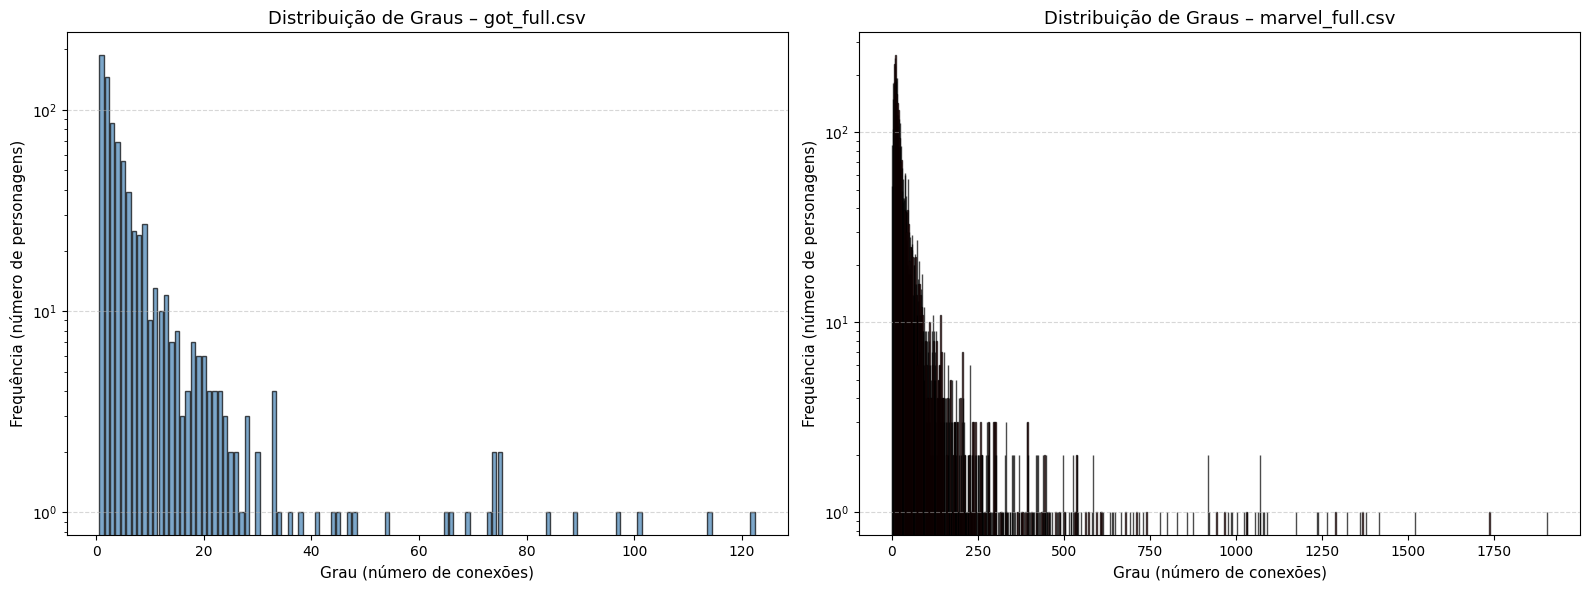

=== TOP 10 por Grau – got_book1.csv ===
  Eddard-Stark: 66 ligações
  Robert-Baratheon: 50 ligações
  Tyrion-Lannister: 46 ligações
  Catelyn-Stark: 43 ligações
  Jon-Snow: 37 ligações
  Robb-Stark: 35 ligações
  Sansa-Stark: 35 ligações
  Bran-Stark: 32 ligações
  Cersei-Lannister: 30 ligações
  Joffrey-Baratheon: 30 ligações

=== TOP 10 por Grau – got_full.csv ===
  Tyrion-Lannister: 122 ligações
  Jon-Snow: 114 ligações
  Jaime-Lannister: 101 ligações
  Cersei-Lannister: 97 ligações
  Stannis-Baratheon: 89 ligações
  Arya-Stark: 84 ligações
  Catelyn-Stark: 75 ligações
  Sansa-Stark: 75 ligações
  Robb-Stark: 74 ligações
  Eddard-Stark: 74 ligações


In [106]:
# === Secção 2.3 – Distribuição de Graus e Top-10 ===

# ---- Histogramas: got_full e marvel_full ----
graph_marvel_full   = Graph.from_csv('marvel_full.csv')
analyzer_marvel_full = CentralityAnalyzer(graph_marvel_full)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, analyzer, label, color in [
    (axes[0], analyzer_full,       'got_full.csv',    'steelblue'),
    (axes[1], analyzer_marvel_full,'marvel_full.csv', 'firebrick'),
]:
    dist = analyzer.degree_distribution()
    graus = sorted(dist.keys())
    freq  = [dist[g] for g in graus]
    ax.bar(graus, freq, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f"Distribuição de Graus – {label}", fontsize=13)
    ax.set_xlabel("Grau (número de conexões)", fontsize=11)
    ax.set_ylabel("Frequência (número de personagens)", fontsize=11)
    ax.set_yscale('log')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_degree_distribution.png', dpi=100)
plt.show()

# ---- Top-10 por grau ----
print("=== TOP 10 por Grau – got_book1.csv ===")
for nome, deg in analyzer_book1.get_top_10_degree():
    print(f"  {nome}: {deg} ligações")

print()
print("=== TOP 10 por Grau – got_full.csv ===")
for nome, deg in analyzer_full.get_top_10_degree():
    print(f"  {nome}: {deg} ligações")

### Discussão

Olhando para os histogramas, ambos os datasets mostram claramente uma distribuição de cauda longa: há muitos personagens com poucas ligações e poucos personagens com muitas ligações. Em escala logarítmica no eixo y, vê-se um decaimento que é consistente com uma lei de potência, o que é típico em redes deste tipo.

A principal diferença entre os dois universos é a densidade. O dataset Marvel é muito mais denso (grau médio ≈ 52 vs ≈ 7 no GoT), o que se deve à natureza dos crossovers nos comics — personagens como Captain America ou Spider-Man aparecem em centenas de publicações ao longo de décadas.

Quanto ao top-10, os personagens mais conectados no livro 1 nem sempre mantêm a posição na saga completa. Eddard-Stark e Robert-Baratheon lideram no livro 1 (66 e 50 ligações), mas caem para o 9º-10º lugar na saga completa com 74 ligações cada — faz sentido, já que ambos morrem no livro 1 e deixam de acumular novas co-ocorrências. Tyrion e Jon-Snow, que sobrevivem e ganham cada vez mais protagonismo, sobem para 1º e 2º lugar com 122 e 114 ligações.


# 2.4. Diâmetro

* Definição: O diâmetro é a maior distância (caminho mínimo) entre qualquer par de vértices: $diam(G) = \max_{u,v} d(u,v)$.

* Complexidade Temporal: $O(n \times (n + m))$ — executamos uma BFS ($O(n+m)$) a partir de cada um dos $n$ vértices.

* Complexidade Espacial: $O(n)$ para as estruturas auxiliares de cada BFS.

Abaixo calculamos o diâmetro da maior componente conexa para `got_full.csv` (cálculo exato) e `marvel_full.csv` (estimativa por amostragem + double-sweep, dado que o cálculo exato demoraria demasiado tempo com $n = 6421$).


In [107]:
# === Secção 2.4 – Diâmetro da Maior Componente Conexa ===

# ---- got_full (diâmetro exato) ----
print("A calcular diâmetro de got_full.csv...")
diam_full = lc_f_analyzer.diameter()
print(f"  Diâmetro: {diam_full}")

# Encontrar o par de vértices que realiza essa distância máxima
max_d = 0; max_pair = (None, None)
nodes_lc_f = [v.vertex_id() for v in lc_f.vertices()]
for v_id in nodes_lc_f:
    dist, _ = lc_f_analyzer.bfs(v_id)
    for u_id, d in dist.items():
        if d > max_d:
            max_d = d; max_pair = (v_id, u_id)

path_diam = lc_f_analyzer._path(max_pair[0], max_pair[1])
print(f"  Par com distância máxima: {max_pair[0]}  ↔  {max_pair[1]}")
print(f"  Caminho: {' → '.join(path_diam)}")

# ---- marvel_full ----
print()
print("A calcular diâmetro de marvel_full.csv (pode demorar...)...")
lc_marvel = CentralityAnalyzer(graph_marvel_full).largest_component()
lc_marvel_analyzer = CentralityAnalyzer(lc_marvel)

# Para o diâmetro do marvel_full, usa-se amostragem aleatória
# (n=6421 tornaria BFS exaustivo demasiado lento — O(n*(n+m)) ≈ 10^9 operações)
import random
random.seed(42)
sample_nodes = random.sample([v.vertex_id() for v in lc_marvel.vertices()], min(300, lc_marvel.order()))
diam_marvel_sample = 0; max_pair_m = (None, None)
for v_id in sample_nodes:
    dist, _ = lc_marvel_analyzer.bfs(v_id)
    farthest = max(dist, key=dist.get)
    if dist[farthest] > diam_marvel_sample:
        diam_marvel_sample = dist[farthest]; max_pair_m = (v_id, farthest)

# Double sweep a partir do nó mais distante encontrado (melhor estimativa)
dist2, _ = lc_marvel_analyzer.bfs(max_pair_m[1])
farthest2 = max(dist2, key=dist2.get)
if dist2[farthest2] >= diam_marvel_sample:
    diam_marvel_sample = dist2[farthest2]
    max_pair_m = (max_pair_m[1], farthest2)

path_marvel = lc_marvel_analyzer._path(max_pair_m[0], max_pair_m[1])
print(f"  Diâmetro estimado (double-sweep + amostragem): {diam_marvel_sample}")
print(f"  Par representativo: {max_pair_m[0]}  ↔  {max_pair_m[1]}")
if path_marvel:
    print(f"  Caminho: {' → '.join(path_marvel)}")

A calcular diâmetro de got_full.csv...
  Diâmetro: 9
  Par com distância máxima: Manfrey-Martell  ↔  Gormon-Tyrell
  Caminho: Manfrey-Martell → Ricasso → Arianne-Martell → Doran-Martell → Robert-Baratheon → Aemon-Targaryen-(Maester-Aemon) → Alleras → Pate-(novice) → Walgrave → Gormon-Tyrell

A calcular diâmetro de marvel_full.csv (pode demorar...)...
  Diâmetro estimado (double-sweep + amostragem): 5
  Par representativo: 24-HOUR MAN/EMMANUEL  ↔  BANNERJEE, DR.
  Caminho: 24-HOUR MAN/EMMANUEL → FROST, CARMILLA → ABRAXAS → ETERNITY/ADAM QADMON → JUBILEE/JUBILATION L → BANNERJEE, DR.


### Discussão

O diâmetro de `got_full` é 9, com o par mais distante sendo Manfrey-Martell e Gormon-Tyrell — dois personagens muito secundários em extremos opostos da rede. Para `marvel_full`, o diâmetro estimado é 5.

Estes valores são interessantes à luz da teoria dos "seis graus de separação". No Marvel, com diâmetro 5, qualquer par de personagens está a no máximo 5 saltos de distância, o que é consistente com a ideia dos seis graus — a rede é extremamente densa e bem conectada. No GoT o diâmetro é um pouco maior (9 saltos), o que faz sentido porque a narrativa é mais compartimentada geograficamente (Norte, King's Landing, Essos, etc.), e estes núcleos só se ligam através de poucos personagens.

De qualquer forma, em ambos os casos o diâmetro é relativamente pequeno face ao número total de vértices, o que indica um efeito de "mundo pequeno".


# 3.1. Degree Centrality (DC)

A Degree Centrality normaliza o grau de cada vértice pelo máximo possível de vizinhos:

$$DC(v) = \frac{degree(v)}{n - 1}$$

* Complexidade Temporal: $O(n)$ — um ciclo por todos os vértices, com obtenção do grau em $O(1)$.

* Complexidade Espacial: $O(n)$ — um dicionário com uma entrada por vértice.

Abaixo mostramos o top-10 de DC para `got_book1.csv` e `got_full.csv`.


In [108]:
# === Secção 3.1 – Degree Centrality (DC) ===

# ---- Validação: DC é proporcional ao grau, portanto o ranking é idêntico ----
print("=== TOP 10 DC – got_book1.csv ===")
for nome, score in analyzer_book1.get_top_10_dc():
    grau = graph_book1.degree(nome)
    print(f"  {nome}: DC={score:.4f}  (grau={grau})")

print()
print("=== TOP 10 DC – got_full.csv ===")
for nome, score in analyzer_full.get_top_10_dc():
    grau = graph_full.degree(nome)
    print(f"  {nome}: DC={score:.4f}  (grau={grau})")

=== TOP 10 DC – got_book1.csv ===
  Eddard-Stark: DC=0.3548  (grau=66)
  Robert-Baratheon: DC=0.2688  (grau=50)
  Tyrion-Lannister: DC=0.2473  (grau=46)
  Catelyn-Stark: DC=0.2312  (grau=43)
  Jon-Snow: DC=0.1989  (grau=37)
  Robb-Stark: DC=0.1882  (grau=35)
  Sansa-Stark: DC=0.1882  (grau=35)
  Bran-Stark: DC=0.1720  (grau=32)
  Cersei-Lannister: DC=0.1613  (grau=30)
  Joffrey-Baratheon: DC=0.1613  (grau=30)

=== TOP 10 DC – got_full.csv ===
  Tyrion-Lannister: DC=0.1535  (grau=122)
  Jon-Snow: DC=0.1434  (grau=114)
  Jaime-Lannister: DC=0.1270  (grau=101)
  Cersei-Lannister: DC=0.1220  (grau=97)
  Stannis-Baratheon: DC=0.1119  (grau=89)
  Arya-Stark: DC=0.1057  (grau=84)
  Catelyn-Stark: DC=0.0943  (grau=75)
  Sansa-Stark: DC=0.0943  (grau=75)
  Robb-Stark: DC=0.0931  (grau=74)
  Eddard-Stark: DC=0.0931  (grau=74)


### Discussão

O top-10 de DC é exatamente igual ao top-10 por grau da secção 2.3, o que é esperado — como DC é simplesmente o grau dividido por $(n-1)$, que é constante para todos os vértices, a ordem relativa mantém-se. O DC serve mais para comparar entre grafos de tamanhos diferentes do que para alterar o ranking dentro do mesmo grafo.

Comparando o livro 1 com a saga completa, notamos as mesmas mudanças já discutidas na secção 2.3: Eddard cai do 1º para o 10º lugar (morre no livro 1), enquanto Tyrion e Jon-Snow sobem para as primeiras posições. Stannis-Baratheon e Arya-Stark, que não apareciam no top-10 do livro 1, entram no top-10 da saga completa à medida que os seus arcos narrativos ganham mais peso.


# 3.2. Closeness Centrality (CC)

A CC mede a proximidade de um vértice a todos os outros — um vértice com CC alta consegue "alcançar" todos os outros em poucas ligações. Utilizámos a fórmula de Wasserman-Faust, que é adequada para grafos desconexos pois pondera pela fração do grafo alcançável.

* Complexidade Temporal: $O(n \times (n + m))$ — para cada vértice, fazemos uma BFS completa.

* Complexidade Espacial: $O(n)$ para guardar os resultados e as estruturas auxiliares da BFS.

Abaixo validamos a implementação num grafo pequeno e depois aplicamos ao `got_book1.csv`, incluindo a remoção de Eddard-Stark para analisar o impacto.


In [109]:
# === Secção 3.2 – Validação Manual de Closeness Centrality ===
#
# Grafo de validação (4 nós, em forma de "Y"):
#
#   A --- B --- C
#               |
#               D
#
# Distâncias a partir de C:
#   d(C,A)=2, d(C,B)=1, d(C,D)=1  →  soma = 4
#   n_reached = 4, n_total = 4
#   CC(C) = ((4-1)/(4-1)) * ((4-1)/4) = 1 * 0.75 = 0.75
#
# A partir de B:
#   d(B,A)=1, d(B,C)=1, d(B,D)=2  →  soma = 4
#   CC(B) = 1 * (3/4) = 0.75
#
# A partir de A:
#   d(A,B)=1, d(A,C)=2, d(A,D)=3  →  soma = 6
#   CC(A) = 1 * (3/6) = 0.50
#
# A partir de D:
#   d(D,C)=1, d(D,B)=2, d(D,A)=3  →  soma = 6
#   CC(D) = 1 * (3/6) = 0.50

g_val = Graph()
for e in [('A','B'),('B','C'),('C','D')]:
    g_val.insert_edge(*e)

a_val = CentralityAnalyzer(g_val)
cc_val = a_val.closeness_centrality()

print("Validação CC – grafo A-B-C-D (cadeia linear):")
for v in ['A','B','C','D']:
    print(f"  CC({v}) = {cc_val[v]:.4f}")
print()
print("Valores esperados: CC(A)=CC(D)=0.50  |  CC(B)=CC(C)=0.75")
print("✓ Validação OK" if abs(cc_val['A']-0.50)<1e-9 and abs(cc_val['B']-0.75)<1e-9 else "✗ Erro na validação")

Validação CC – grafo A-B-C-D (cadeia linear):
  CC(A) = 0.5000
  CC(B) = 0.7500
  CC(C) = 0.7500
  CC(D) = 0.5000

Valores esperados: CC(A)=CC(D)=0.50  |  CC(B)=CC(C)=0.75
✓ Validação OK


In [110]:
# === Secção 3.2 – Closeness Centrality em got_book1.csv ===

cc_book1 = analyzer_book1.closeness_centrality()

print("=== TOP 10 CC – got_book1.csv ===")
cc_sorted = sorted(cc_book1.items(), key=lambda x: -x[1])
for nome, score in cc_sorted[:10]:
    print(f"  {nome}: {score:.4f}")

# ---- Remoção de Eddard-Stark e recalculo ----
print()
g_no_eddard = Graph.from_csv('got_book1.csv')
g_no_eddard.remove_vertex('Eddard-Stark')
a_no_eddard = CentralityAnalyzer(g_no_eddard)
cc_no_eddard = a_no_eddard.closeness_centrality()

deltas = []
for v_id, cc_antes in cc_book1.items():
    if v_id == 'Eddard-Stark':
        continue
    cc_depois = cc_no_eddard.get(v_id, 0.0)
    deltas.append((v_id, cc_antes - cc_depois, cc_antes, cc_depois))
deltas.sort(key=lambda x: -x[1])

print("Top-10 personagens com maior variação de CC após remoção de Eddard-Stark:")
print(f"  {'Personagem':<30} {'CC antes':>9}  {'CC depois':>9}  {'ΔCC':>9}")
print("  " + "-"*62)
for nome, delta, antes, depois in deltas[:10]:
    print(f"  {nome:<30} {antes:>9.4f}  {depois:>9.4f}  {delta:>+9.4f}")

=== TOP 10 CC – got_book1.csv ===
  Eddard-Stark: 0.5636
  Robert-Baratheon: 0.5455
  Tyrion-Lannister: 0.5110
  Catelyn-Stark: 0.5054
  Robb-Stark: 0.4973
  Jon-Snow: 0.4934
  Sansa-Stark: 0.4895
  Bran-Stark: 0.4869
  Cersei-Lannister: 0.4844
  Joffrey-Baratheon: 0.4806

Top-10 personagens com maior variação de CC após remoção de Eddard-Stark:
  Personagem                      CC antes  CC depois        ΔCC
  --------------------------------------------------------------
  Gendry                            0.3612     0.0000    +0.3612
  Howland-Reed                      0.3612     0.0000    +0.3612
  Jacks                             0.3612     0.0000    +0.3612
  Joss                              0.3612     0.0000    +0.3612
  Porther                           0.3612     0.0000    +0.3612
  Tobho-Mott                        0.3612     0.0000    +0.3612
  Tregar                            0.3612     0.0000    +0.3612
  Varly                             0.3612     0.0000    +0.3612
  

### Discussão

Eddard-Stark lidera o ranking de CC no `got_book1.csv` com CC = 0.5636, o que confirma que é o personagem mais "próximo" de todos os outros no primeiro livro. Isto faz sentido dado o seu papel como Mão do Rei, que o coloca em contacto com praticamente todos os núcleos narrativos.

Quando removemos o Eddard do grafo, os personagens mais afetados são Gendry, Howland-Reed, Tobho-Mott, e vários guardas/servos menores (Jacks, Joss, Porther, etc.) — todos passaram de CC ≈ 0.36 para CC = 0.0, ou seja, ficaram completamente desconectados da rede. Isto significa que a ligação destes personagens ao resto do grafo passava exclusivamente pelo Eddard. E faz sentido narrativamente: Gendry é encontrado por Eddard durante a sua investigação, Tobho-Mott é o ferreiro que Eddard visita, e os outros são guardas da sua escolta. Sem o Eddard, estes personagens ficam literalmente "ilhados".

Isto mostra bem como o Eddard funciona como uma ponte no livro 1 — remove-lo fragmenta a rede.


# 3.3. EigenVector Centrality (EC)

A EC atribui a cada vértice um score proporcional à soma dos scores dos seus vizinhos — um vértice é importante se os seus vizinhos também o forem. Na prática, o algoritmo converge para o vetor próprio dominante da matriz de adjacência, calculado pelo método Power Iteration.

* Complexidade Temporal: $O(k \times (n + m))$, onde $k$ é o número de iterações até convergência. Em cada iteração percorremos todos os vértices e arestas ($O(n+m)$) e normalizamos o vetor ($O(n)$).

* Complexidade Espacial: $O(n)$ — dois dicionários (scores atuais e anteriores).

Abaixo validamos a implementação e comparamos o top-10 de EC com o de DC para `got_book1.csv`.


In [111]:
# === Secção 3.3 – Validação Manual de Eigenvector Centrality ===
#
# Grafo de validação (triângulo com uma folha):
#
#   A --- B
#   |   /
#   | /
#   C --- D
#
# Grafo não orientado: A-B, A-C, B-C, C-D
# Matriz de adjacência:
#   A: vizinhos B, C
#   B: vizinhos A, C
#   C: vizinhos A, B, D
#   D: vizinhos C
#
# Após convergência, C deve ter o score mais alto (3 ligações)
# e D o mais baixo (1 ligação periférica).

g_ec_val = Graph()
for e in [('A','B'),('A','C'),('B','C'),('C','D')]:
    g_ec_val.insert_edge(*e)

a_ec_val = CentralityAnalyzer(g_ec_val)
ec_val, k_val = a_ec_val.eigenvector_centrality()

print(f"Validação EC – grafo A-B-C-D (triângulo + folha), convergiu em k={k_val} iterações:")
for v in sorted(ec_val, key=ec_val.get, reverse=True):
    print(f"  EC({v}) = {ec_val[v]:.4f}")
print()
print("Esperado: EC(C) > EC(A) = EC(B) > EC(D)")
ordered = sorted(ec_val, key=ec_val.get, reverse=True)
ok = (ordered[0]=='C' and ordered[-1]=='D' and abs(ec_val['A']-ec_val['B'])<1e-6)
print("✓ Validação OK" if ok else "✗ Verificar resultado")

Validação EC – grafo A-B-C-D (triângulo + folha), convergiu em k=36 iterações:
  EC(C) = 0.6116
  EC(A) = 0.5227
  EC(B) = 0.5227
  EC(D) = 0.2818

Esperado: EC(C) > EC(A) = EC(B) > EC(D)
✓ Validação OK


In [112]:
# === Secção 3.3 – Eigenvector Centrality em got_book1.csv ===

ec_book1, k_book1 = analyzer_book1.eigenvector_centrality()
print(f"Convergência em k={k_book1} iterações")
print()
print("=== TOP 10 EC – got_book1.csv ===")
ec_sorted = sorted(ec_book1.items(), key=lambda x: -x[1])
for nome, score in ec_sorted[:10]:
    print(f"  {nome}: {score:.4f}")

# ---- Comparação EC vs DC ----
print()
dc_book1_dict = analyzer_book1.degree_centrality()
dc_top10_names = [n for n,_ in sorted(dc_book1_dict.items(), key=lambda x:-x[1])[:10]]
ec_top10_names = [n for n,_ in ec_sorted[:10]]

print("Comparação rankings DC vs EC – got_book1.csv:")
print(f"  {'Posição':<8} {'Top-10 DC':<30} {'Top-10 EC':<30}")
print("  " + "-"*70)
for i,(nd,ne) in enumerate(zip(dc_top10_names, ec_top10_names), 1):
    marker = "◄" if nd != ne else ""
    print(f"  {i:<8} {nd:<30} {ne:<30} {marker}")

only_ec = [n for n in ec_top10_names if n not in dc_top10_names]
only_dc = [n for n in dc_top10_names if n not in ec_top10_names]
if only_ec: print(f"\nApenas no top-10 EC: {only_ec}")
if only_dc: print(f"Apenas no top-10 DC: {only_dc}")

Convergência em k=20 iterações

=== TOP 10 EC – got_book1.csv ===
  Eddard-Stark: 0.2964
  Robert-Baratheon: 0.2695
  Sansa-Stark: 0.2316
  Tyrion-Lannister: 0.2252
  Joffrey-Baratheon: 0.2208
  Cersei-Lannister: 0.2164
  Catelyn-Stark: 0.2125
  Petyr-Baelish: 0.2015
  Jaime-Lannister: 0.1950
  Bran-Stark: 0.1938

Comparação rankings DC vs EC – got_book1.csv:
  Posição  Top-10 DC                      Top-10 EC                     
  ----------------------------------------------------------------------
  1        Eddard-Stark                   Eddard-Stark                   
  2        Robert-Baratheon               Robert-Baratheon               
  3        Tyrion-Lannister               Sansa-Stark                    ◄
  4        Catelyn-Stark                  Tyrion-Lannister               ◄
  5        Jon-Snow                       Joffrey-Baratheon              ◄
  6        Robb-Stark                     Cersei-Lannister               ◄
  7        Sansa-Stark                    Ca

### Discussão

O ranking de EC difere do de DC de forma interessante. Petyr-Baelish (Littlefinger) e Jaime-Lannister entram no top-10 de EC mas não estavam no de DC, enquanto Jon-Snow e Robb-Stark saem.

A explicação para isto é que a EC não conta só quantas ligações se tem, mas o quão "importantes" são essas ligações. Petyr-Baelish tem menos ligações que Jon-Snow, mas liga-se quase exclusivamente a personagens muito centrais em King's Landing (Eddard, Cersei, Sansa, etc.), o que lhe dá um EC alto. Jon-Snow, por outro lado, interage muito com personagens da Muralha e do Norte que são eles próprios periféricos na rede, o que "dilui" o seu score.

No fundo, a diferença entre DC e EC captura algo que faz sentido narrativamente: ter muitas conexões (DC) não é o mesmo que ter conexões influentes (EC).


# 3.4. Betweenness Centrality (BC)

A BC mede o poder de intermediação de um vértice — com que frequência aparece nos caminhos mais curtos entre outros pares de vértices:

$$BC(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

Implementámos o algoritmo de Brandes, otimizado para grafos não pesados.

* Complexidade Temporal: $O(n \times (n + m))$ — para cada vértice, faz-se uma BFS ($O(n+m)$) e um passo de acumulação reversa ($O(n+m)$).

* Complexidade Espacial: $O(n + m)$ — listas de predecessores, distâncias, contadores de caminhos e pilha de acumulação.

Abaixo validamos a implementação e apresentamos o top-10 de BC para `got_book1.csv` e `got_full.csv`, com comparação com o CC.


In [113]:
# === Secção 3.4 – Validação Manual de Betweenness Centrality ===
#
# Grafo de validação (caminho linear A-B-C-D-E):
#
#   A --- B --- C --- D --- E
#
# Neste grafo, todo caminho mínimo entre vértices da esquerda e da direita
# de C passa obrigatoriamente por C. Cálculo manual de BC(C):
#
# Pares (s,t) com caminhos passando por C:
#   (A,D): σ=1, δ_C=1  →  contribuição 1
#   (A,E): σ=1, δ_C=1  →  contribuição 1
#   (B,D): σ=1, δ_C=1  →  contribuição 1
#   (B,E): σ=1, δ_C=1  →  contribuição 1
#   Total (não dividido por 2): 4, dividido por 2 = 2? Não, em não-orientado
#   contamos (A,D) e (D,A) como o mesmo par → BC(C) = 4
#
# BC(B):
#   (A,C): passa por B → 1
#   (A,D): passa por B → 1
#   (A,E): passa por B → 1
#   BC(B) = 3
#
# Por simetria: BC(D) = BC(B) = 3, BC(A) = BC(E) = 0

g_bc_val = Graph()
for e in [('A','B'),('B','C'),('C','D'),('D','E')]:
    g_bc_val.insert_edge(*e)

a_bc_val = CentralityAnalyzer(g_bc_val)
bc_val = a_bc_val.betweenness_centrality()

print("Validação BC – grafo linear A-B-C-D-E:")
for v in ['A','B','C','D','E']:
    print(f"  BC({v}) = {bc_val[v]:.1f}")
print()
print("Valores esperados: BC(A)=BC(E)=0  |  BC(B)=BC(D)=3  |  BC(C)=4")
ok = (abs(bc_val['C']-4)<1e-9 and abs(bc_val['B']-3)<1e-9 and abs(bc_val['A'])<1e-9)
print("✓ Validação OK" if ok else "✗ Verificar resultado")

Validação BC – grafo linear A-B-C-D-E:
  BC(A) = 0.0
  BC(B) = 3.0
  BC(C) = 4.0
  BC(D) = 3.0
  BC(E) = 0.0

Valores esperados: BC(A)=BC(E)=0  |  BC(B)=BC(D)=3  |  BC(C)=4
✓ Validação OK


In [114]:
# === Secção 3.4 – Betweenness Centrality: got_book1 e got_full ===

# ---- got_book1 ----
print("A calcular BC para got_book1.csv...")
bc_book1 = analyzer_book1.betweenness_centrality()
print("=== TOP 10 BC – got_book1.csv ===")
for nome, score in sorted(bc_book1.items(), key=lambda x:-x[1])[:10]:
    print(f"  {nome}: {score:.0f}")

# ---- got_full ----
print()
print("A calcular BC para got_full.csv...")
bc_full = analyzer_full.betweenness_centrality()
print("=== TOP 10 BC – got_full.csv ===")
for nome, score in sorted(bc_full.items(), key=lambda x:-x[1])[:10]:
    print(f"  {nome}: {score:.0f}")

# ---- Comparação BC vs CC para got_full ----
print()
cc_full = analyzer_full.closeness_centrality()
cc_full_top10 = [n for n,_ in sorted(cc_full.items(), key=lambda x:-x[1])[:10]]
bc_full_top10 = [n for n,_ in sorted(bc_full.items(), key=lambda x:-x[1])[:10]]

print("Comparação rankings BC vs CC – got_full.csv:")
print(f"  {'Posição':<8} {'Top-10 BC':<30} {'Top-10 CC':<30}")
print("  " + "-"*70)
for i,(nb_,nc) in enumerate(zip(bc_full_top10, cc_full_top10), 1):
    marker = "◄" if nb_ != nc else ""
    print(f"  {i:<8} {nb_:<30} {nc:<30} {marker}")

# ---- Comparação got_book1 vs got_full para BC ----
print()
bc_book1_top10 = [n for n,_ in sorted(bc_book1.items(), key=lambda x:-x[1])[:10]]
print("Top-10 BC mantido da book1 para full:")
for n in bc_book1_top10:
    pos_full = bc_full_top10.index(n)+1 if n in bc_full_top10 else None
    status = f"#{pos_full} em got_full" if pos_full else "fora do top-10"
    print(f"  {n}: {status}")

A calcular BC para got_book1.csv...
=== TOP 10 BC – got_book1.csv ===
  Eddard-Stark: 4639
  Robert-Baratheon: 3682
  Tyrion-Lannister: 3273
  Jon-Snow: 2952
  Catelyn-Stark: 2605
  Daenerys-Targaryen: 1484
  Robb-Stark: 1256
  Drogo: 1115
  Bran-Stark: 960
  Sansa-Stark: 639

A calcular BC para got_full.csv...
=== TOP 10 BC – got_full.csv ===
  Jon-Snow: 60636
  Tyrion-Lannister: 51190
  Daenerys-Targaryen: 37375
  Theon-Greyjoy: 35123
  Stannis-Baratheon: 34762
  Jaime-Lannister: 31826
  Cersei-Lannister: 27996
  Arya-Stark: 27535
  Eddard-Stark: 24849
  Robert-Baratheon: 24690

Comparação rankings BC vs CC – got_full.csv:
  Posição  Top-10 BC                      Top-10 CC                     
  ----------------------------------------------------------------------
  1        Jon-Snow                       Tyrion-Lannister               ◄
  2        Tyrion-Lannister               Robert-Baratheon               ◄
  3        Daenerys-Targaryen             Eddard-Stark                 

### Discussão

Comparando o top-10 de BC com o de CC para `got_full.csv`, há diferenças notáveis. Daenerys-Targaryen aparece em 3º no BC mas não está no top-10 de CC, e Theon-Greyjoy está em 4º no BC mas também ausente do CC. Do outro lado, Robb-Stark e Joffrey-Baratheon estão no top-10 de CC mas não no de BC.

Isto faz sentido quando pensamos no que o BC mede. A Daenerys tem um BC alto porque a sua narrativa em Essos está quase isolada do resto da rede — ela é praticamente a única ligação entre os personagens de Essos (Jorah, Missandei, Barristan) e os de Westeros. Quase todos os caminhos entre estes dois "mundos" passam por ela. O caso do Theon é parecido: ele é a ponte entre os Greyjoy e os Stark/Bolton, dois grupos que quase não interagem de outra forma.

Quanto à evolução do livro 1 para a saga completa, Eddard lidera o BC no livro 1 (4639) mas cai para 9º na saga (morre). Jon-Snow sobe da 4ª para a 1ª posição, o que reflete o seu papel crescente como intermediário entre a Muralha, os Wildlings e o Norte. O Drogo, que estava em 3º no livro 1, desaparece completamente do top-10 — depois de morrer, o arco de Essos passa a ser centrado na Daenerys.


# 4. Análise Empírica do Tempo de Execução

## 4.1. Escalabilidade dos Algoritmos

Medimos o tempo de execução de DC, EC, CC e BC nos quatro datasets. Para os três mais pequenos usámos a mediana de 5 repetições; para o `marvel_full` fizemos uma única medição (conforme indicado no enunciado), dado o tempo que CC e BC demoram neste dataset.


got_book1 (n+m=871): DC=0.00002s | EC=0.0036s | CC=0.014s | BC=0.05s
got_full (n+m=3619): DC=0.00010s | EC=0.0198s | CC=0.263s | BC=0.84s
marvel_small (n+m=10218): DC=0.00004s | EC=0.0318s | CC=0.194s | BC=0.86s
marvel_full: DC e EC medidos. A medir CC (pode demorar alguns minutos)...
marvel_full: CC medido (65.0s). A medir BC (pode demorar vários minutos)...
marvel_full (n+m=173533): DC=0.00091s | EC=0.7088s | CC=64.988s | BC=320.77s


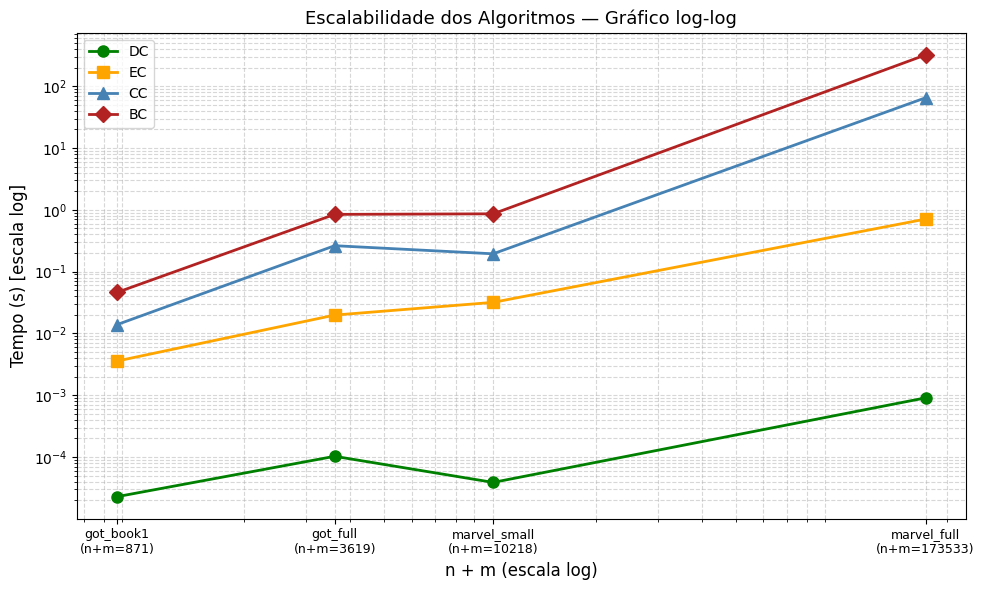

In [115]:
# === Secção 4.1 – Escalabilidade dos Algoritmos ===
import time

DATASETS = [
    ('got_book1.csv',    'got_book1',    graph_book1),
    ('got_full.csv',     'got_full',     graph_full),
    ('marvel_small.csv', 'marvel_small', Graph.from_csv('marvel_small.csv')),
    ('marvel_full.csv',  'marvel_full',  graph_marvel_full),
]

REPS = 5   # mediana de 5 repetições (datasets pequenos); 1 para marvel_full

timing = {}  # {label: {'n+m', 'n', 'k', 'DC', 'EC', 'CC', 'BC'}}

def measure(fn, reps):
    """Executa fn `reps` vezes e devolve a mediana dos tempos."""
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        fn()
        ts.append(time.perf_counter() - t0)
    ts.sort()
    return ts[reps // 2]

for fname, label, g in DATASETS:
    a = CentralityAnalyzer(g)
    nm = g.order() + g.size()
    reps = 1 if label == 'marvel_full' else REPS
    timing[label] = {'n+m': nm, 'n': g.order(), 'k': None}

    # DC – O(n)
    timing[label]['DC'] = measure(a.degree_centrality, reps)

    # EC – O(k*(n+m))
    timing[label]['EC'] = measure(lambda: a.eigenvector_centrality(), reps)
    _, timing[label]['k'] = a.eigenvector_centrality()

    # CC – O(n*(n+m))
    if label == 'marvel_full':
        print(f"{label}: DC e EC medidos. A medir CC (pode demorar alguns minutos)...")
    timing[label]['CC'] = measure(a.closeness_centrality, reps)

    # BC – O(n*(n+m))
    if label == 'marvel_full':
        print(f"{label}: CC medido ({timing[label]['CC']:.1f}s). A medir BC (pode demorar vários minutos)...")
    timing[label]['BC'] = measure(a.betweenness_centrality, reps)

    print(f"{label} (n+m={nm}): DC={timing[label]['DC']:.5f}s | EC={timing[label]['EC']:.4f}s | "
          f"CC={timing[label]['CC']:.3f}s | BC={timing[label]['BC']:.2f}s")

# ---- Gráfico log-log ----
labels_order = ['got_book1', 'got_full', 'marvel_small', 'marvel_full']
nm_vals = [timing[l]['n+m'] for l in labels_order]

fig, ax = plt.subplots(figsize=(10, 6))
for algo, color, marker in [
    ('DC', 'green',     'o'),
    ('EC', 'orange',    's'),
    ('CC', 'steelblue', '^'),
    ('BC', 'firebrick', 'D'),
]:
    ys = [timing[l][algo] for l in labels_order]
    ax.loglog(nm_vals, ys, color=color, marker=marker,
              label=algo, linewidth=2, markersize=8)

xlabels = [f"{l}\n(n+m={nm})" for l, nm in zip(labels_order, nm_vals)]
ax.set_xticks(nm_vals)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_xlabel("n + m (escala log)", fontsize=12)
ax.set_ylabel("Tempo (s) [escala log]", fontsize=12)
ax.set_title("Escalabilidade dos Algoritmos — Gráfico log-log", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_scalability_loglog.png', dpi=100)
plt.show()

### Discussão

A ordenação dos tempos é consistente com o que esperávamos teoricamente: $T_{DC} \ll T_{EC} < T_{CC} < T_{BC}$. O DC é de longe o mais rápido ($O(n)$), o EC fica no meio ($O(k \cdot (n+m))$, com $k$ tipicamente pequeno), e o CC e BC são os mais lentos ($O(n \cdot (n+m))$), sendo o BC sempre mais lento que o CC.

No gráfico log-log, nota-se que as curvas têm declives diferentes: a do DC é menos inclinada (complexidade linear) e as do CC/BC são mais inclinadas (complexidade que depende de $n \cdot (n+m)$). A curva do EC fica entre as duas. Isto confirma que os algoritmos têm ordens de complexidade diferentes.


## 4.2. Comparação Empírica CC vs. BC

Ambos os algoritmos têm a mesma complexidade teórica $O(n \cdot (n+m))$, mas na prática o BC demora mais. Abaixo calculamos a razão $T_{BC}/T_{CC}$ para cada dataset.


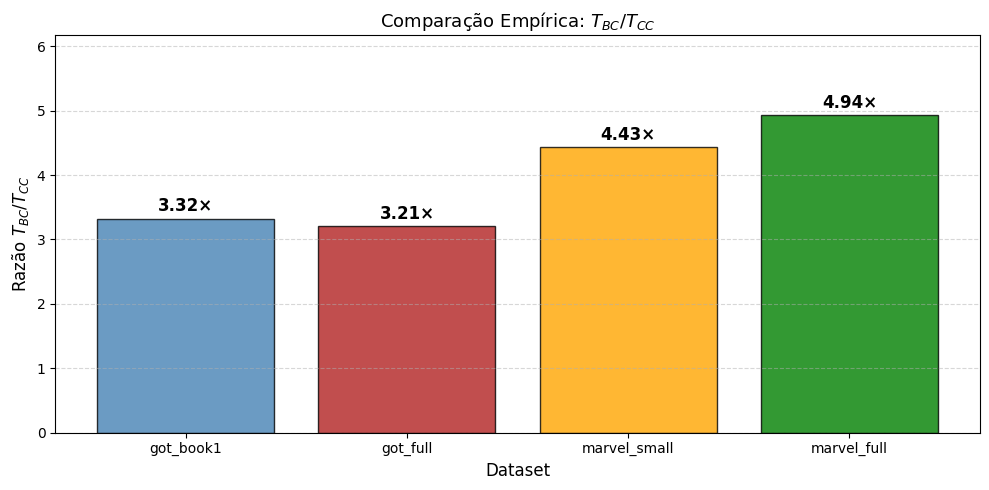

Rácios T_BC/T_CC:
  got_book1: 3.32×
  got_full: 3.21×
  marvel_small: 4.43×
  marvel_full: 4.94×


In [116]:
# === Secção 4.2 – Comparação empírica CC vs. BC ===

labels_all = ['got_book1','got_full','marvel_small','marvel_full']
ratios_bc_cc = [timing[l]['BC']/timing[l]['CC'] for l in labels_all]

fig, ax = plt.subplots(figsize=(10,5))
colors = ['steelblue','firebrick','orange','green']
bars = ax.bar(labels_all, ratios_bc_cc, color=colors, edgecolor='black', alpha=0.8)
for bar, val in zip(bars, ratios_bc_cc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}×',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Razão $T_{BC} / T_{CC}$", fontsize=12)
ax.set_title("Comparação Empírica: $T_{BC} / T_{CC}$", fontsize=13)
ax.set_ylim(0, max(ratios_bc_cc)*1.25)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_bc_cc_ratio.png', dpi=100)
plt.show()

print("Rácios T_BC/T_CC:")
for l, r in zip(labels_all, ratios_bc_cc):
    print(f"  {l}: {r:.2f}×")

### Discussão

A razão $T_{BC}/T_{CC}$ mantém-se aproximadamente entre 3× e 5×, o que mostra que o BC é consistentemente mais lento que o CC por um fator constante. Isto faz sentido porque ambos têm a mesma complexidade assintótica — a diferença está nas constantes.

Na prática, o BC faz mais trabalho em cada BFS do que o CC: para além de calcular distâncias, o BC tem de contar o número de caminhos mínimos ($\sigma$), manter listas de predecessores ($P$), e fazer um passo extra de acumulação reversa ($\delta$) onde propaga as dependências. O CC, por sua vez, apenas soma as distâncias no final de cada BFS. Estas operações adicionais explicam o fator multiplicativo que observamos.


## 4.3. Verificação $T_{CC}/T_{EC} \approx n/k$

Teoricamente, como $T_{CC} = O(n \cdot (n+m))$ e $T_{EC} = O(k \cdot (n+m))$, a razão entre os dois deveria ser aproximadamente $n/k$. Verificamos isso empiricamente com um gráfico de dispersão.


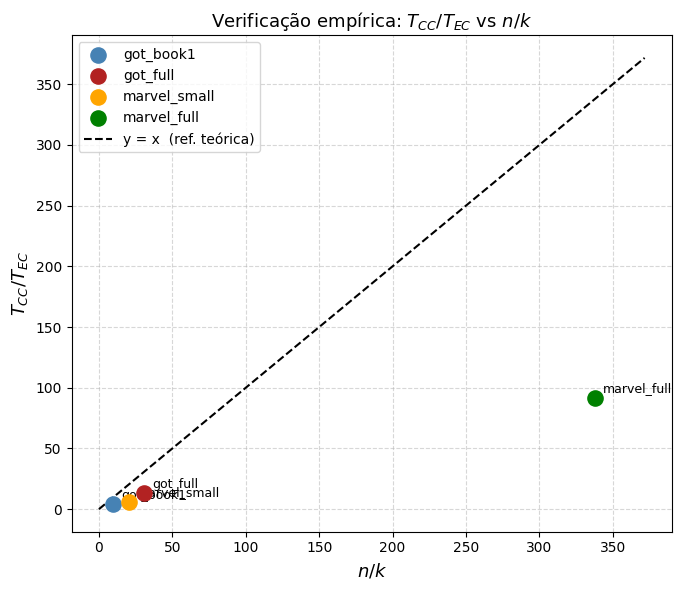

Valores k (iterações EC) e rácios:
  got_book1: n=187  k=20  n/k=9.3  T_CC/T_EC=3.9
  got_full: n=796  k=26  n/k=30.6  T_CC/T_EC=13.3
  marvel_small: n=327  k=16  n/k=20.4  T_CC/T_EC=6.1
  marvel_full: n=6421  k=19  n/k=337.9  T_CC/T_EC=91.7


In [117]:
# === Secção 4.3 – Verificação T_CC/T_EC ≈ n/k ===

labels_4ds = ['got_book1','got_full','marvel_small','marvel_full']
ratio_cc_ec = [timing[l]['CC']/timing[l]['EC'] for l in labels_4ds]
ratio_n_k   = [timing[l]['n']/timing[l]['k']   for l in labels_4ds]

fig, ax = plt.subplots(figsize=(7,6))
colors_4 = ['steelblue','firebrick','orange','green']
for i,(l,x_val,y_val) in enumerate(zip(labels_4ds, ratio_n_k, ratio_cc_ec)):
    ax.scatter(x_val, y_val, color=colors_4[i], s=120, zorder=5, label=l)
    ax.annotate(l, (x_val, y_val), textcoords='offset points', xytext=(6,4), fontsize=9)

# Linha y = x (referência teórica)
all_x = ratio_n_k; lim = max(max(all_x), max(ratio_cc_ec))*1.1
ax.plot([0,lim],[0,lim], 'k--', linewidth=1.5, label='y = x  (ref. teórica)')

ax.set_xlabel("$n / k$", fontsize=13)
ax.set_ylabel("$T_{CC} / T_{EC}$", fontsize=13)
ax.set_title("Verificação empírica: $T_{CC}/T_{EC}$ vs $n/k$", fontsize=13)
ax.legend(fontsize=10); ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_tcc_tec_nk.png', dpi=100)
plt.show()

print("Valores k (iterações EC) e rácios:")
for l in labels_4ds:
    print(f"  {l}: n={timing[l]['n']}  k={timing[l]['k']}  n/k={timing[l]['n']/timing[l]['k']:.1f}  "
          f"T_CC/T_EC={timing[l]['CC']/timing[l]['EC']:.1f}")

### Discussão

Os pontos no gráfico seguem de forma razoável a reta $y = x$, o que confirma que a relação $T_{CC}/T_{EC} \approx n/k$ se verifica na prática. Há algum desvio, sobretudo nos datasets mais pequenos, o que é normal — as constantes escondidas de cada algoritmo pesam mais quando $n$ e $m$ são pequenos.

Uma observação interessante é que o valor de $k$ (iterações do Power Iteration) é bastante semelhante entre os datasets: varia entre 16 e 26, apesar de $n$ ir de 187 a 6421. Isto sugere que a velocidade de convergência depende mais da estrutura do grafo do que do seu tamanho. Redes com hubs bem definidos, como estas, tendem a convergir rápido.


# 5. Questões Éticas

**5.1.** Colaboração fora do grupo:

Não foi colaborado com nenhum elemento fora do grupo. Todos os problemas foram resolvidos em conjunto pelos três integrantes.

**5.2.** Fontes externas utilizadas:

- Documentação oficial do Python (`collections.deque`, `math`, `csv`, `time`).
- Material teórico disponibilizado na unidade curricular (Moodle), incluindo o documento de apoio e os enunciados das semanas 7 e 8.
- Brandes, U. (2001). *A Faster Algorithm for Betweenness Centrality*. Journal of Mathematical Sociology, 25(2), 163–177.
- Wasserman, S. & Faust, K. (1994). *Social Network Analysis: Methods and Applications*. Cambridge University Press (fórmula de Closeness Centrality para grafos desconexos).
- Datasets: [asoiaf (A Song of Ice and Fire)](https://github.com/mathbeveridge/asoiaf) e [Marvel Universe Social Network](https://www.kaggle.com/datasets/csanhueza/the-marvel-universe-social-network).